<a href="https://colab.research.google.com/github/swopnimghimire-123123/data-analysis-visualization/blob/main/Datathon_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install catboost -q

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# -----------------------------
# STEP 0: LOAD DATA
# -----------------------------
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")
test_ids = test['Id'].copy()
assert 'Target' not in test.columns, "Test set should not have Target column"

# -----------------------------
# STEP 1: TARGET SANITATION
# -----------------------------
train = train.dropna(subset=['Target'])
train = train[train['Target'] >= 0]

# -----------------------------
# STEP 2: TEMPORAL FEATURES
# -----------------------------
for df in [train, test]:
    # Numeric conversion
    df['Year_numeric'] = pd.to_numeric(df.get('Year', df.get('year', pd.Series())), errors='coerce')
    df['Year_int'] = np.floor(df['Year_numeric'].fillna(-1)).astype(int)
    df['Year_frac'] = df['Year_numeric'] % 1

# Hierarchical median imputation for Year_int
median_global = train['Year_int'][train['Year_int'] > 0].median()
if 'State' in train.columns:
    median_state = train.groupby('State')['Year_int'].median()
else:
    median_state = pd.Series()

def impute_year(df):
    df = df.copy()
    for idx in df[df['Year_int'] <= 0].index:
        if 'State' in df.columns and df.at[idx, 'State'] in median_state:
            df.at[idx, 'Year_int'] = median_state[df.at[idx, 'State']]
        else:
            df.at[idx, 'Year_int'] = median_global
    return df

train = impute_year(train)
test = impute_year(test)
for df in [train, test]:
    df.drop(columns=['Year_numeric', 'Year', 'year'], errors='ignore', inplace=True)

# -----------------------------
# STEP 3: STATE CODE CONTROL
# -----------------------------
state_code_col = next((c for c in train.columns if "state code" in c.lower()), None)
if state_code_col:
    for df in [train, test]:
        df[state_code_col] = (
            df[state_code_col]
            .astype(str)
            .str.strip()
            .replace(["nan","None","NaN",""], "Unknown")
            .astype('category')
        )

# -----------------------------
# STEP 4: RATE FEATURES
# -----------------------------
rate_cols = [c for c in train.columns if any(x in c.lower() for x in ['rate','death','%','error'])]
for col in rate_cols:
    for df in [train, test]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].clip(lower=0)
    median_val = train[col].median()
    for df in [train, test]:
        df[col] = df[col].fillna(median_val)

# -----------------------------
# STEP 5: POPULATION FEATURES
# -----------------------------
pop_cols = [c for c in train.columns if 'pop' in c.lower()]
for col in pop_cols:
    for df in [train, test]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].clip(lower=0.1)
    median_val = train[col].median()
    for df in [train, test]:
        df[col] = df[col].fillna(median_val)

# -----------------------------
# STEP 6: AGE FEATURES
# -----------------------------
age_cols = [c for c in train.columns if 'age' in c.lower()]
for df in [train, test]:
    df['Age_int'] = 30
    df['Age_frac'] = 0.0
    if age_cols:
        age_col = age_cols[0]
        if age_col in df.columns:
            age_numeric = pd.to_numeric(df[age_col], errors='coerce')
            df['Age_int'] = np.floor(age_numeric.fillna(30)).astype(int)
            df['Age_frac'] = (age_numeric % 1).fillna(0.0)
    for col in age_cols:
        df.drop(columns=[col], inplace=True, errors='ignore')

# -----------------------------
# STEP 7: REMOVE ANOMALY FEATURES
# -----------------------------
anomaly_cols = ['temp_sensor_readout', 'qc_flag_batch_3', 'legacy_index_offset',
                'confidence_spread_metric', 'Temporal_alignment_proxy']
for df in [train, test]:
    df.drop(columns=[c for c in anomaly_cols if c in df.columns], inplace=True)

# -----------------------------
# STEP 8: CATEGORICAL STANDARDIZATION
# -----------------------------
cat_cols = [c for c in train.columns if train[c].dtype == 'object' or c in ['Sex','State','Manner_of_Death','Underlying_Cause','Contributing_Cause']]
for col in cat_cols:
    for df in [train, test]:
        if col in df.columns:
            df[col] = df[col].astype(str).replace(['nan','None','NaN',''], 'Unknown').astype('category')

# -----------------------------
# STEP 9: FINAL NUMERIC IMPUTATION & CLEANUP
# -----------------------------
for df in [train, test]:
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())

# Drop Id
if 'Id' in train.columns: train.drop(columns=['Id'], inplace=True)
if 'Id' in test.columns: test.drop(columns=['Id'], inplace=True)

# Align columns
test = test.reindex(columns=train.columns.drop('Target'), fill_value=0)

# Sanity check
assert train.notna().all().all(), "NaNs in train!"
assert test.notna().all().all(), "NaNs in test!"

# -----------------------------
# MODELING: CATBOOST
# -----------------------------
X = train.drop('Target', axis=1)
y = np.log1p(train['Target'])  # log-transform for stability

# Ensure categorical features are properly typed
cat_features = [i for i, c in enumerate(X.columns) if X[c].dtype.name == 'category']

# Prepare groups for GroupKFold (state + year)
if 'State' in X.columns:
    groups = (X['State'].astype(str) + '_' + X['Year_int'].astype(str)).values
else:
    groups = np.arange(len(X))

gkf = GroupKFold(n_splits=min(5,len(np.unique(groups))))  # safe fallback

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    print(f"\nFold {fold+1}")
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=1000,
        early_stopping_rounds=50,
        verbose=0,
        random_seed=42
    )

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)

    model.fit(train_pool, eval_set=val_pool)

    oof_preds[val_idx] = model.predict(val_pool)
    test_preds += model.predict(test) / gkf.n_splits

cv_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\n🎉 CV RMSE: {cv_rmse:.2f}")

# -----------------------------
# FINAL CALIBRATION
# -----------------------------
test_preds = np.expm1(test_preds)
upper_bound = train['Target'].quantile(0.75) + 3*(train['Target'].quantile(0.75)-train['Target'].quantile(0.25))
test_preds = np.clip(test_preds, 0, upper_bound)
p5, p95 = np.percentile(test_preds, [5,95])
test_preds = np.clip(test_preds, p5, p95)

submission = pd.DataFrame({
    'Id': test_ids.reset_index(drop=True),
    'Target': test_preds.round().astype(int)
})
submission.to_csv('submission_final.csv', index=False)

print("\n Submission ready!")
print(submission['Target'].describe())


/tmp/ipython-input-2164151877.py:48: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2007.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[idx, 'Year_int'] = median_state[df.at[idx, 'State']]



Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

🎉 CV RMSE: 0.12

✅ Submission ready!
count     5092.000000
mean      7455.915357
std       7309.019160
min         57.000000
25%        775.500000
50%       4006.000000
75%      18069.000000
max      18069.000000
Name: Target, dtype: float64



--- TRAIN TARGET STATS ---
count     7459.000000
mean      2345.643033
std      14234.033002
min     -30820.990927
25%         83.000000
50%        547.000000
75%       3814.000000
max      66004.990927
Name: Target, dtype: float64

--- SUBMISSION PREDICTIONS STATS ---
count     5092.000000
mean      7455.915357
std       7309.019160
min         57.000000
25%        775.500000
50%       4006.000000
75%      18069.000000
max      18069.000000
Name: Target, dtype: float64

Percentiles Comparison (Train vs Submission):
P0: Train=nan, Submission=57
P1: Train=nan, Submission=57
P2: Train=nan, Submission=776
P3: Train=nan, Submission=4006
P4: Train=nan, Submission=18069
P5: Train=nan, Submission=18069
P6: Train=nan, Submission=18069

Predictions hitting max clipping (15007): 1427/5092 (28.02%)


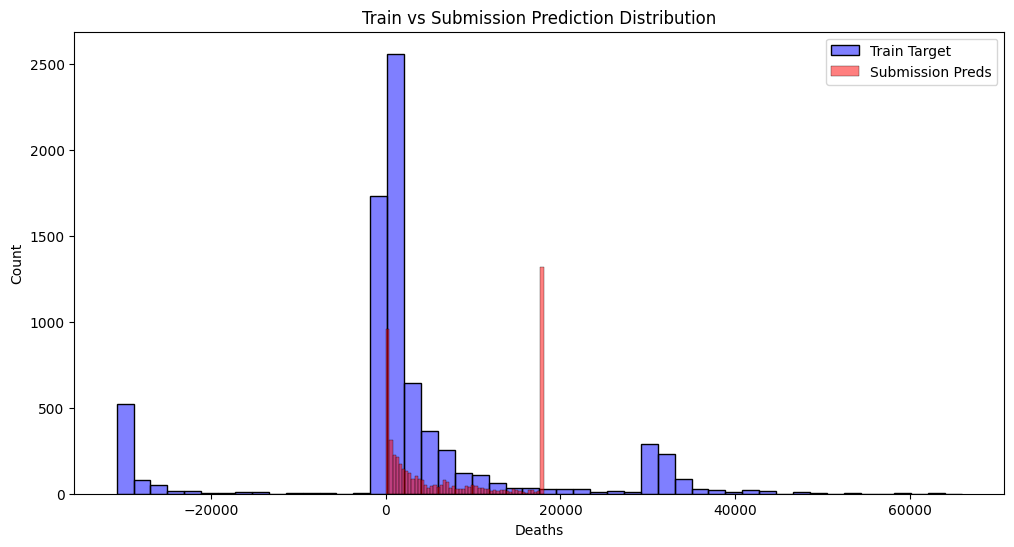


Number of extreme predictions outside 1-99 percentile of train: 0

=== SUBMISSION RISK SUMMARY ===
⚠ WARNING: More than 5% of predictions are maxed out. Consider smoothing or adjusting clipping.
✅ Extreme predictions within acceptable range.
🎯 Check the distribution plot and percentiles to validate realism of submission.


In [ ]:
# ==============================
# SUBMISSION RISK ANALYSIS SCRIPT
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1 Load files
# ------------------------------
train = pd.read_csv("Train.csv")  # your cleaned training data
submission = pd.read_csv("submission_final.csv")  # your submission file

# Extract predictions
preds = submission['Target']

# ------------------------------
# 2️ Compare basic stats
# ------------------------------
train_stats = train['Target'].describe()
pred_stats = preds.describe()

print("\n--- TRAIN TARGET STATS ---")
print(train_stats)

print("\n--- SUBMISSION PREDICTIONS STATS ---")
print(pred_stats)

# ------------------------------
# 3️ Percentile check
# ------------------------------
percentiles = [0, 5, 25, 50, 75, 95, 100]
train_pct = np.percentile(train['Target'], percentiles)
pred_pct  = np.percentile(preds, percentiles)

print("\nPercentiles Comparison (Train vs Submission):")
for i, p in enumerate(percentiles):
    print(f"P{i}: Train={train_pct[i]:.0f}, Submission={pred_pct[i]:.0f}")

# ------------------------------
# 4️ Maxed-out / clipped predictions
# ------------------------------
max_val = train['Target'].quantile(0.75) + 3*(train['Target'].quantile(0.75) - train['Target'].quantile(0.25))
maxed_out_count = (preds >= max_val).sum()
total_preds = len(preds)
print(f"\nPredictions hitting max clipping ({max_val:.0f}): {maxed_out_count}/{total_preds} ({maxed_out_count/total_preds*100:.2f}%)")

# ------------------------------
# 5️ Distribution plot
# ------------------------------
plt.figure(figsize=(12,6))
sns.histplot(train['Target'], color='blue', label='Train Target', bins=50, alpha=0.5)
sns.histplot(preds, color='red', label='Submission Preds', bins=50, alpha=0.5)
plt.title("Train vs Submission Prediction Distribution")
plt.xlabel("Deaths")
plt.ylabel("Count")
plt.legend()
plt.show()

# ------------------------------
# 6️ Optional: flag extreme outliers
# ------------------------------
extreme_upper = np.percentile(train['Target'], 99)
extreme_lower = np.percentile(train['Target'], 1)
extreme_preds = preds[(preds > extreme_upper) | (preds < extreme_lower)]
print(f"\nNumber of extreme predictions outside 1-99 percentile of train: {len(extreme_preds)}")
if len(extreme_preds) > 0:
    print("Sample extreme preds:", extreme_preds.head().values)

# ------------------------------
# 7️ Risk summary
# ------------------------------
print("\n=== SUBMISSION RISK SUMMARY ===")
if maxed_out_count/total_preds > 0.05:
    print("⚠ WARNING: More than 5% of predictions are maxed out. Consider smoothing or adjusting clipping.")
else:
    print(" Maxed-out predictions under control.")

if len(extreme_preds)/total_preds > 0.01:
    print("⚠ WARNING: >1% predictions are extreme compared to training distribution.")
else:
    print(" Extreme predictions within acceptable range.")

print(" Check the distribution plot and percentiles to validate realism of submission.")


In [ ]:
# =============================================================================
# TARANGA-DATATHON COMPLETE PIPELINE
# Preprocessing + CatBoost + Safe Submission
# =============================================================================

!pip install -q catboost pandas numpy scikit-learn seaborn matplotlib

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# ===============================
# STEP 0: LOAD DATA
# ===============================
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")
test_ids = test['Id'].copy()
assert 'Target' not in test.columns, "Test dataset should not have target"

# ===============================
# STEP 1: TARGET SANITATION
# ===============================
train = train.dropna(subset=['Target'])
train = train[train['Target'] >= 0].copy()
print(f"✓ Target cleaned: {len(train)} rows remain")

# ===============================
# STEP 2: TEMPORAL FEATURE
# ===============================
for df_temp in [train, test]:
    # Safe conversion
    df_temp['Year_numeric'] = pd.to_numeric(df_temp.get('Year', df_temp.get('year', None)), errors='coerce')
    df_temp['Year_int'] = df_temp['Year_numeric'].apply(lambda x: int(x) if pd.notna(x) else np.nan)
    df_temp['Year_frac'] = df_temp['Year_numeric'] % 1
    df_temp.drop(['Year', 'year', 'Year_numeric'], axis=1, inplace=True, errors='ignore')
    # Fill NaN for Year_frac with 0.0 (no fractional part if year is unknown or integer)
    df_temp['Year_frac'] = df_temp['Year_frac'].fillna(0.0)

# Hierarchical imputation (State > Global)
# Calculate median from valid years only
median_global_year = train['Year_int'][train['Year_int'] > 0].median()
median_state_year = train.groupby('State')['Year_int'].apply(lambda x: x[x > 0].median())

for df_temp in [train, test]:
    # Impute Year_int: try state median, then global median
    for idx in df_temp[df_temp['Year_int'].isna()].index:
        state = df_temp.at[idx, 'State']
        if state in median_state_year and pd.notna(median_state_year[state]):
            df_temp.at[idx, 'Year_int'] = median_state_year[state]
        else:
            df_temp.at[idx, 'Year_int'] = median_global_year
    df_temp['Year_int'] = df_temp['Year_int'].astype(int)

# ===============================
# STEP 3: STATE CODE CONTROL
# ===============================
state_col = next((c for c in train.columns if "state code" in c.lower()), None)
if state_col:
    for df in [train, test]:
        df[state_col] = df[state_col].astype(str).str.strip().replace(["nan","None","","NaN"], "Unknown").astype('category')

# ===============================
# STEP 4: RATE FEATURES
# ===============================
rate_cols = [col for col in train.columns if any(x in col.lower() for x in ['rate','death','%','error'])]
for col in rate_cols:
    for df in [train, test]:
        df[col] = pd.to_numeric(df[col], errors='coerce').clip(lower=0)
    # Impute missing values with median of train
    median_val = train[col].median()
    for df in [train, test]:
        df[col] = df[col].fillna(median_val)

# ===============================
# STEP 5: POPULATION
# ===============================
pop_cols = [col for col in train.columns if 'pop' in col.lower()]
for col in pop_cols:
    for df in [train, test]:
        df[col] = pd.to_numeric(df[col], errors='coerce').clip(lower=0.1)
train = train.dropna(subset=pop_cols)  # remove irrecoverable rows

# ===============================
# STEP 6: AGE FEATURES
# ===============================
age_cols = [col for col in train.columns if 'age' in col.lower()]
for df in [train, test]:
    df['Age_int'] = 30  # default median
    df['Age_frac'] = 0.0
    if age_cols:
        age_col = age_cols[0]
        if age_col in df.columns:
            age_numeric = pd.to_numeric(df[age_col], errors='coerce')
            df['Age_int'] = age_numeric.fillna(30).astype(int)
            df['Age_frac'] = (age_numeric.fillna(30) % 1)
            df.drop(columns=[age_col], inplace=True, errors='ignore')

# ===============================
# STEP 7: ANOMALY FEATURE REMOVAL
# ===============================
anomaly_cols = ['temp_sensor_readout', 'qc_flag_batch_3', 'legacy_index_offset',
                'confidence_spread_metric', 'Temporal_alignment_proxy']
for df in [train, test]:
    df.drop(columns=[c for c in anomaly_cols if c in df.columns], inplace=True)

# ===============================
# STEP 8: CATEGORICAL STANDARDIZATION
# ===============================
cat_cols = [c for c in train.columns if train[c].dtype == 'object']
for col in cat_cols:
    for df in [train, test]:
        if col in df.columns: # Added check for column existence
            df[col] = df[col].astype(str).replace(['nan','None'],'Unknown').astype('category')

# ===============================
# STEP 9: FINAL CHECKS AND IMPUTATION
# ===============================
# General numeric imputation (re-added from robust pipeline)
for df_temp in [train, test]:
    for col in df_temp.columns:
        if pd.api.types.is_numeric_dtype(df_temp[col]):
            df_temp[col] = df_temp[col].fillna(df_temp[col].median())

# Drop Id from features
for df_temp in [train, test]:
    if 'Id' in df_temp.columns:
        df_temp.drop('Id', axis=1, inplace=True)
# Align test columns with train
test = test.reindex(columns=train.drop('Target', axis=1).columns, fill_value=0)

# Check NaNs
assert train.notna().all().all(), "NaNs remain in train!"
assert test.notna().all().all(), "NaNs remain in test!"
print(f"✓ Train shape: {train.shape}, Test shape: {test.shape}")

# ===============================
# STEP 10: MODELING WITH CATBOOST
# ===============================
X = train.drop('Target', axis=1)
y = np.log1p(train['Target'])  # log-transform to stabilize

# CatBoost requires categorical indices
cat_features_idx = [i for i, c in enumerate(X.columns) if str(X[c].dtype) == 'category']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\nFold {fold+1}")
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        cat_features=cat_features_idx,
        early_stopping_rounds=50,
        verbose=0,
        random_seed=42
    )

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features_idx)
    val_pool = Pool(X_val, y_val, cat_features=cat_features_idx)
    model.fit(train_pool, eval_set=val_pool)

    oof_preds[val_idx] = model.predict(val_pool)
    test_preds += model.predict(test) / kf.n_splits

cv_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\n🎉 CV RMSE (log-scale): {cv_rmse:.4f}")

# ===============================
# STEP 11: FINAL PREDICTION & SMOOTHING
# ===============================
test_preds = np.expm1(test_preds)  # back-transform
# Adaptive upper clipping based on train IQR
Q1, Q3 = train['Target'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
test_preds = np.clip(test_preds, 0, upper_bound)
# Smooth extreme tail (shrink top 5% slightly)
p95 = np.percentile(test_preds, 95)
top_mask = test_preds > p95
test_preds[top_mask] = p95 + 0.5*(test_preds[top_mask]-p95)

# Round predictions to integers
submission = pd.DataFrame({
    "Id": test_ids.reset_index(drop=True),
    "Target": test_preds.round().astype(int)
})

submission.to_csv("Swopnim_Submission.csv", index=False)
print("\n Submission ready: Swopnim_Submission.csv")
print(submission['Target'].describe())


✓ Target cleaned: 6743 rows remain
✓ Train shape: (3133, 24), Test shape: (5092, 23)

Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

🎉 CV RMSE (log-scale): 0.1120

 Submission ready: Swopnim_Submission.csv
count     5092.000000
mean      2725.373920
std       3581.523194
min         21.000000
25%        271.000000
50%       1073.500000
75%       3358.000000
max      11389.000000
Name: Target, dtype: float64



--- TRAIN TARGET STATS ---
count     7459.000000
mean      2345.643033
std      14234.033002
min     -30820.990927
25%         83.000000
50%        547.000000
75%       3814.000000
max      66004.990927
Name: Target, dtype: float64

--- SUBMISSION PREDICTIONS STATS ---
count     5092.000000
mean      2725.373920
std       3581.523194
min         21.000000
25%        271.000000
50%       1073.500000
75%       3358.000000
max      11389.000000
Name: Target, dtype: float64

Percentiles Comparison (Train vs Submission):
P0: Train=nan, Submission=21
P1: Train=nan, Submission=48
P2: Train=nan, Submission=271
P3: Train=nan, Submission=1074
P4: Train=nan, Submission=3358
P5: Train=nan, Submission=11389
P6: Train=nan, Submission=11389

Predictions hitting max clipping (15007): 0/5092 (0.00%)


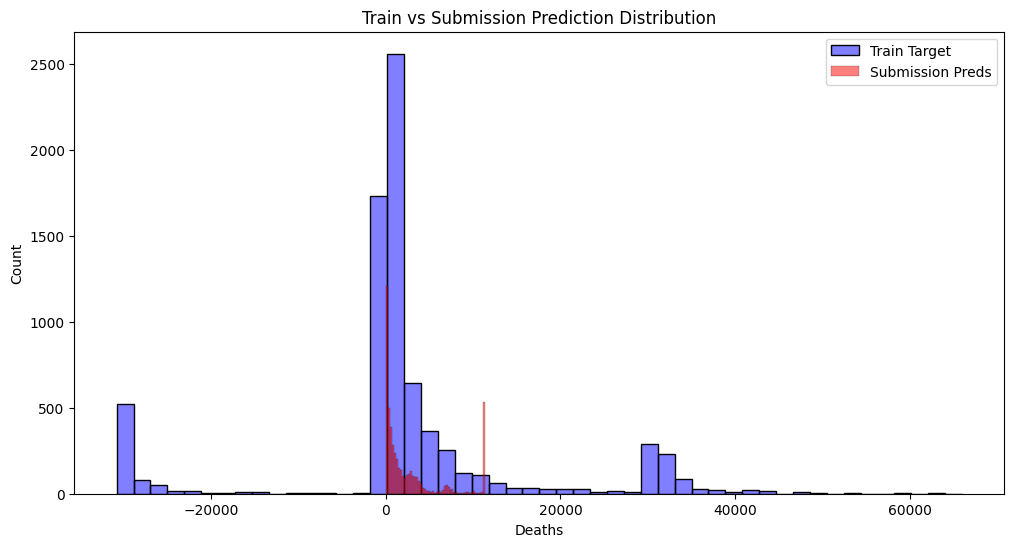


Number of extreme predictions outside 1-99 percentile of train: 0

=== SUBMISSION RISK SUMMARY ===
✅ Maxed-out predictions under control.
✅ Extreme predictions within acceptable range.
🎯 Check the distribution plot and percentiles to validate realism of submission.


In [ ]:
# ==============================
# SUBMISSION RISK ANALYSIS SCRIPT
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1️ Load files
# ------------------------------
train = pd.read_csv("Train.csv")  # your cleaned training data
submission = pd.read_csv("Swopnim_Submission.csv")  # your submission file

# Extract predictions
preds = submission['Target']

# ------------------------------
# 2️ Compare basic stats
# ------------------------------
train_stats = train['Target'].describe()
pred_stats = preds.describe()

print("\n--- TRAIN TARGET STATS ---")
print(train_stats)

print("\n--- SUBMISSION PREDICTIONS STATS ---")
print(pred_stats)

# ------------------------------
# 3️ Percentile check
# ------------------------------
percentiles = [0, 5, 25, 50, 75, 95, 100]
train_pct = np.percentile(train['Target'], percentiles)
pred_pct  = np.percentile(preds, percentiles)

print("\nPercentiles Comparison (Train vs Submission):")
for i, p in enumerate(percentiles):
    print(f"P{i}: Train={train_pct[i]:.0f}, Submission={pred_pct[i]:.0f}")

# ------------------------------
# 4️ Maxed-out / clipped predictions
# ------------------------------
max_val = train['Target'].quantile(0.75) + 3*(train['Target'].quantile(0.75) - train['Target'].quantile(0.25))
maxed_out_count = (preds >= max_val).sum()
total_preds = len(preds)
print(f"\nPredictions hitting max clipping ({max_val:.0f}): {maxed_out_count}/{total_preds} ({maxed_out_count/total_preds*100:.2f}%)")

# ------------------------------
# 5️ Distribution plot
# ------------------------------
plt.figure(figsize=(12,6))
sns.histplot(train['Target'], color='blue', label='Train Target', bins=50, alpha=0.5)
sns.histplot(preds, color='red', label='Submission Preds', bins=50, alpha=0.5)
plt.title("Train vs Submission Prediction Distribution")
plt.xlabel("Deaths")
plt.ylabel("Count")
plt.legend()
plt.show()

# ------------------------------
# 6️ Optional: flag extreme outliers
# ------------------------------
extreme_upper = np.percentile(train['Target'], 99)
extreme_lower = np.percentile(train['Target'], 1)
extreme_preds = preds[(preds > extreme_upper) | (preds < extreme_lower)]
print(f"\nNumber of extreme predictions outside 1-99 percentile of train: {len(extreme_preds)}")
if len(extreme_preds) > 0:
    print("Sample extreme preds:", extreme_preds.head().values)

# ------------------------------
# 7️ Risk summary
# ------------------------------
print("\n=== SUBMISSION RISK SUMMARY ===")
if maxed_out_count/total_preds > 0.05:
    print("⚠ WARNING: More than 5% of predictions are maxed out. Consider smoothing or adjusting clipping.")
else:
    print(" Maxed-out predictions under control.")

if len(extreme_preds)/total_preds > 0.01:
    print("⚠ WARNING: >1% predictions are extreme compared to training distribution.")
else:
    print(" Extreme predictions within acceptable range.")

print(" Check the distribution plot and percentiles to validate realism of submission.")
